In [1]:
import numpy as np
import uproot
import awkward as ak
def summarize_tree(data, tree_name, id_name):
    unique_ids = np.unique(data[id_name])
    print(f"---{tree_name}---")
    print(f" Entries: {len(data)}")
    print(f" Unique {id_name}: {len(unique_ids[unique_ids > 0])}")
    print(f" Noise/BG Entries (ID <= 0): {len(data[data[id_name] <= 0])}")

In [2]:
branches = ["x", "y", "z", "adc", "layer", "event", "hitID"]

with uproot.open("clusters_seeds_island_79507-0.root_ntuplizer.root") as f:
    # We use library="ak" to keep the event structure (jagged arrays)
    hits = f["ntp_hit"].arrays(branches, library="ak")
    hit_tree = f["ntp_hit"]
    hit_ids = hit_tree.arrays(branches, library="ak")
    clusters = f["ntp_cluster"].arrays(["trackID", "event"], library="ak")
    clus_trk = f["ntp_clus_trk"].arrays(["seedID", "event"], library="ak")

summarize_tree(hits, "ntp_hits", "hitID")
summarize_tree(hits, "ntp_hits", "event")
summarize_tree(clusters, "ntp_cluster", "trackID")
summarize_tree(clus_trk, "ntp_clus_trk", "seedID")

---ntp_hits---
 Entries: 27532828
 Unique hitID: 644256
 Noise/BG Entries (ID <= 0): 88
---ntp_hits---
 Entries: 27532828
 Unique event: 100
 Noise/BG Entries (ID <= 0): 0
---ntp_cluster---
 Entries: 3136006
 Unique trackID: 0
 Noise/BG Entries (ID <= 0): 0
---ntp_clus_trk---
 Entries: 221494
 Unique seedID: 124
 Noise/BG Entries (ID <= 0): 0


In [6]:
import uproot
import awkward as ak
import numpy as np

# 1. Load only the physical features for hits
branches = ["x", "y", "z", "adc", "layer", "event", "hitID"]

with uproot.open("clusters_seeds_island_79507-0.root_ntuplizer.root") as f:
    hits = f["ntp_hit"].arrays(branches, library="ak")
    hit_tree = f["ntp_hit"]
    hit_ids = hit_tree.arrays(branches, library="ak")

# 2. Group by event
# In HEP, hits are naturally jagged. Awkward arrays handle this:
# Each element in 'event_grouped_hits' will be one collision event
event_ids = np.unique(hits.event)
unique_ids = np.unique(hit_ids.hitID)
print(f"Total events found: {len(event_ids)}")
print(f"Unique hitIDs found: {unique_ids[:-1]}")
print(f"number of unique particles in this slice: {len(unique_ids)}")

# Example: Get all hit features for Event #74
event_74_mask = (hits.event == 74)
event_74_points = hits[event_74_mask]

# Convert to a standard NumPy array for a Point Cloud model [N_hits, 5]
# Features: [x, y, z, adc, layer]
training_features = ak.to_numpy(ak.zip([
    event_74_points.x, 
    event_74_points.y, 
    event_74_points.z, 
    event_74_points.adc,
    event_74_points.layer
]))

print("Shape for Event 74:", training_features.shape)

Total events found: 100
Unique hitIDs found: [0, 1, 2, 3, 4, 5, ..., 1.51e+08, 1.51e+08, 1.51e+08, 1.51e+08, 1.51e+08]
number of unique particles in this slice: 644257
Shape for Event 74: (448447,)


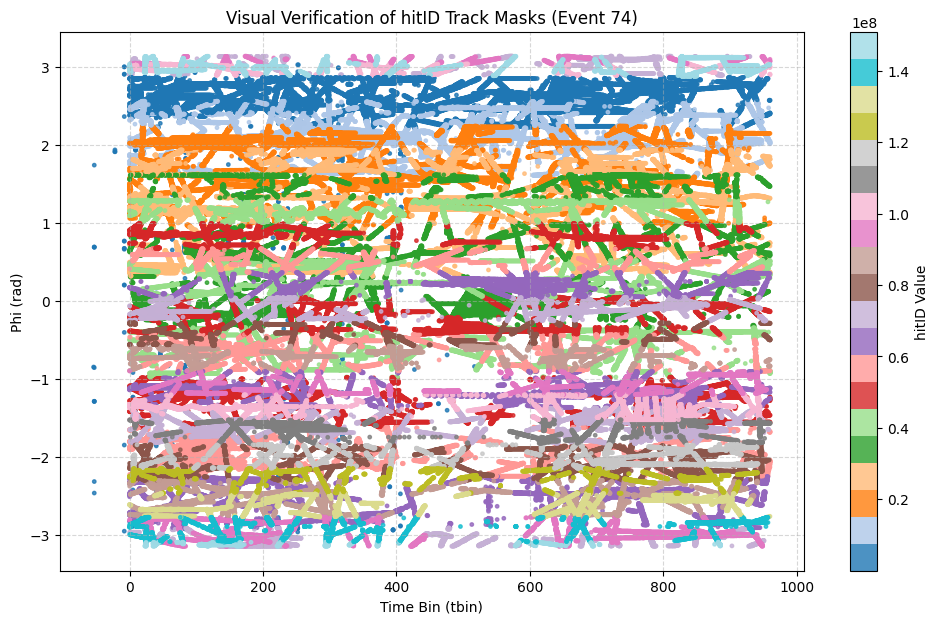

In [20]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd

# 1. Open the latest cycle of ntp_hit
file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"
tree = uproot.open(file_path)["ntp_hit"]

# 2. Extract arrays into a Pandas DataFrame
# Note: Double-check capitalization (e.g., hitID vs hitid) via tree.keys() if needed
df = tree.arrays(["event", "phi", "tbin", "layer", "hitID", "adc"], library="pd")

# 3. Isolate a single event with valid charge deposits
event_id = 74
event_df = df[(df["event"] == event_id) & (df["adc"] > 0)]

# 4. Plot Phi vs Time Bin, color-coded by hitID
plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    event_df["tbin"], 
    event_df["phi"], 
    c=event_df["hitID"], 
    cmap="tab20",  # Qualitative map helps separate discrete ID clusters
    s=6, 
    alpha=0.8
)

plt.colorbar(scatter, label="hitID Value")
plt.xlabel("Time Bin (tbin)")
plt.ylabel("Phi (rad)")
plt.title(f"Visual Verification of hitID Track Masks (Event {event_id})")
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("Event74VisualCheck.png")
plt.show()

In [ ]:
# import uproot
# import pandas as pd
# import numpy as np

# # 1. Open the file and load the tree
# file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"
# tree = uproot.open(file_path)["ntp_hit"]

# # 2. Extract arrays into Pandas (Load only what we need to save memory)
# print("Reading tracking trees from ROOT file...")
# df = tree.arrays(["event", "layer", "hitID", "adc"], library="pd")

# # Filter out dead channels / zero-suppression hits immediately
# df = df[df["adc"] > 0]

# print(f"Total active hits extracted across all events: {len(df):,}")

# # 3. Perform a thorough aggregate analysis per event
# print("\nAuditing dataset structure per event...")
# event_grouped = df.groupby("event")

# event_metrics = event_grouped.agg(
#     total_hits=("hitID", "count"),
#     unique_tracks=("hitID", "nunique"),
#     min_layer=("layer", "min"),
#     max_layer=("layer", "max")
# ).reset_index()

# # Calculate the average tracking cluster density per event
# event_metrics["avg_hits_per_track"] = event_metrics["total_hits"] / event_metrics["unique_tracks"]

# # 4. Display Global Dataset Health Summary
# print("\n" + "="*50)
# print("          GLOBAL DATASET HEALTH REPORT          ")
# print("="*50)
# print(f"Total unique collision events found : {len(event_metrics)}")
# print(f"Average hits per event (multiplicity): {event_metrics['total_hits'].mean():.1f}")
# print(f"Average unique tracks per event      : {event_metrics['unique_tracks'].mean():.1f}")
# print(f"Average hit points per single track  : {event_metrics['avg_hits_per_track'].mean():.1f}")
# print(f"Global detector layer range span     : Layer {int(df['layer'].min())} to Layer {int(df['layer'].max())}")
# print("="*50)

# # 5. Check for ML Ground-Truth Red Flags
# print("\nRunning automated ML data integrity validation checks...")

# # Check for orphan hits (Unassigned track IDs often labeled as -1 or 0 depending on setup)
# noise_labels = [-1, 0]
# for noise_val in noise_labels:
#     noise_count = (df["hitID"] == noise_val).sum()
#     if noise_count > 0:
#         pct_noise = (noise_count / len(df)) * 180
#         print(f"  [⚠️ WARNING] Found {noise_count:,} hits with hitID == {noise_val} ({pct_noise:.2f}% of data).")
#         print(f"               These are background noise/artifacts. Mask them or treat them as a dedicated class.")

# # Check for single-hit anomalies (Tracks that only have 1 hit total across the entire event)
# track_counts = df.groupby(["event", "hitID"]).size().reset_index(name="track_size")
# single_hit_tracks = track_counts[track_counts["track_size"] == 1]
# if len(single_hit_tracks) > 0:
#     print(f"  [⚠️ WARNING] Found {len(single_hit_tracks)} single-hit track instances.")
#     print(f"               Real physics tracks span multiple layers. These are likely standalone hot-pads.")
# else:
#     print("  [✓ PASSED] No single-hit track anomalies found.")

# # Save the full event table for your records/plots
# event_metrics.to_csv("global_event_summary.csv", index=False)
# print("\nThorough examination complete. Summary table saved to 'global_event_summary.csv'.")

Reading tracking trees from ROOT file...
Total active hits extracted across all events: 25,869,501

Auditing dataset structure per event...

          GLOBAL DATASET HEALTH REPORT          
Total unique collision events found : 100
Average hits per event (multiplicity): 258695.0
Average unique tracks per event      : 102114.6
Average hit points per single track  : 2.5
Global detector layer range span     : Layer 3 to Layer 56

Running automated ML data integrity validation checks...
  [⚠️ WARNING] Found 88 hits with hitID == 0 (0.00% of data).
               These are background noise/artifacts. Mask them or treat them as a dedicated class.
  [⚠️ WARNING] Found 4503441 single-hit track instances.
               Real physics tracks span multiple layers. These are likely standalone hot-pads.

Thorough examination complete. Summary table saved to 'global_event_summary.csv'.
